In [ ]:
! pip install pandas openpyxl
! pip install seaborn
! pip install streamlit seaborn matplotlib pandas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import unicodedata
import re

In [ ]:
# Ler a planilha da HomePass
file_path = r"C:\Users\wnsos\OneDrive\Escritorio\Claro\Cluster_projeto_area_tecnica\bases\cluster_node_fev.xlsx"
df = pd.read_excel(file_path, sheet_name="cluster")

# Ver primeiras linhas
df.head()

c:\Users\wnsos\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,DAT_MOVIMENTO,DESC_CIDADE,COD_NODE,COD_NODE_TRAT,COD_IBGE,COD_TIPO_EDIFICACAO,DSC_AREA_DESPACHO,AREA,CLUSTER_GEOGRAFICO,CHAVE_NODE_IBGE
0,01/02/26,SAO PAULO,AALAA,AALAA,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAA_3550308
1,01/02/26,SAO PAULO,AALAB,AALAB,3550308,MULTIPLO,AREA 53,Capital (Área 2),SP,AALAB_3550308
2,01/02/26,SAO PAULO,AALAC,AALAC,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAC_3550308
3,01/02/26,SAO PAULO,AALAD,AALAD,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAD_3550308
4,01/02/26,SAO PAULO,AALAE,AALAE,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAE_3550308


In [3]:
# Padronizar nomes das cidades

def normalizar_texto(texto):
    if pd.isnull(texto):
        return texto
    
    # remover acentos
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ASCII', 'ignore').decode('utf-8')
    
    # remover espaços duplicados
    texto = re.sub(r'\s+', ' ', texto)
    
    # strip e upper
    texto = texto.strip().upper()
    
    return texto

In [4]:
# Aplicar a função de normalização na coluna de cidade

df['DESC_CIDADE_NORM'] = df['DESC_CIDADE'].apply(normalizar_texto)

In [5]:
# Verififcar se há duplicidade no COD_IBGE

df.groupby('DESC_CIDADE_NORM')['COD_IBGE'].nunique().sort_values(ascending=False).head(10)

DESC_CIDADE_NORM
ALUMINIO           1
ARUJA              1
JUNDIAI            1
MAIRINQUE          1
MAUA               1
MOGI DAS CRUZES    1
OSASCO             1
POA                1
RIBEIRAO PIRES     1
SALTO              1
Name: COD_IBGE, dtype: int64

In [6]:
# Padropnizar o nome das colunas, que tem colunas com espaços nos nomes

df.columns = df.columns.str.strip().str.upper()

In [7]:
# Padronizar NODE

def normalizar_node(texto):
    if pd.isnull(texto):
        return texto
    
    texto = str(texto).strip().upper()
    return texto

In [8]:
df['COD_NODE_NORM'] = df['COD_NODE_TRAT'].apply(normalizar_node)

In [9]:
# Verificar quantos valores nulos existem na chve NODE_IBGE

resumo = {
    "df_total": len(df),
    "df_cod_node_null": df['COD_NODE_NORM'].isnull().sum()
}

resumo

{'df_total': 29334, 'df_cod_node_null': 0}

In [10]:
# Alterar o nome da variável DSC_AREA_TECNICA para AREA_TECNICA

df.rename(columns={'DSC_AREA_DESPACHO': 'AREA_TECNICA'}, inplace=True)

In [11]:
# Verificar quantas ficaram sem área técnica atribuída

df['AREA_TECNICA'].isnull().sum()

0

In [12]:
df.head()

,DAT_MOVIMENTO,DESC_CIDADE,COD_NODE,COD_NODE_TRAT,COD_IBGE,COD_TIPO_EDIFICACAO,AREA_TECNICA,AREA,CLUSTER_GEOGRAFICO,CHAVE_NODE_IBGE,DESC_CIDADE_NORM,COD_NODE_NORM
0,01/02/26,SAO PAULO,AALAA,AALAA,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAA_3550308,SAO PAULO,AALAA
1,01/02/26,SAO PAULO,AALAB,AALAB,3550308,MULTIPLO,AREA 53,Capital (Área 2),SP,AALAB_3550308,SAO PAULO,AALAB
2,01/02/26,SAO PAULO,AALAC,AALAC,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAC_3550308,SAO PAULO,AALAC
3,01/02/26,SAO PAULO,AALAD,AALAD,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAD_3550308,SAO PAULO,AALAD
4,01/02/26,SAO PAULO,AALAE,AALAE,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAE_3550308,SAO PAULO,AALAE


In [13]:
# Verificar quantas chaves cada cidade possui

df.groupby('DESC_CIDADE_NORM')['COD_NODE_NORM'].nunique().sort_values(ascending=False)

DESC_CIDADE_NORM
SAO PAULO                 4049
ARUJA                     3344
ITATIBA                   2649
VARZEA PAULISTA           2315
ITUPEVA                   2258
CAMPO LIMPO PAULISTA      2179
SAO ROQUE                 1847
JARINU                    1563
RIBEIRAO PIRES            1492
ITAQUAQUECETUBA           1296
CAIEIRAS                   996
CAJAMAR                    714
CABREUVA                   546
GUARULHOS                  452
OSASCO                     449
SANTO ANDRE                368
MAIRINQUE                  355
SAO BERNARDO DO CAMPO      351
ALUMINIO                   338
BARUERI                    290
JUNDIAI                    215
MOGI DAS CRUZES            200
SAO CAETANO DO SUL         122
DIADEMA                    100
COTIA                       92
MAUA                        85
CARAPICUIBA                 81
SALTO                       74
SANTANA DE PARNAIBA         72
EMBU DAS ARTES              67
BRAGANCA PAULISTA           66
ITU                   

In [15]:
# Ler a planilha da Técnica
file_path = r"C:\Users\wnsos\OneDrive\Escritorio\Claro\Cluster_projeto_area_tecnica\bases\Base_Qualinet.xlsx"
df_tec = pd.read_excel(file_path, sheet_name="Planilha1")

# Ver primeiras linhas
df_tec.head()

,PERÍODO,REGIONAL,SIGLA,SUBCLUSTER,CIDADE,AREA,NODE,GRUPO,HPs,DOMICILIO,PAYTV,PTV DIGITAL,PTV HD,VIRTUA,NETFONE,EBT PME,COD CIDADE + AREA
0,2026-02-01,TODAS,AMIO,SUBCLUSTER SÃO ROQUE,ALUMINIO,AREA ALUMINIO,3501152-SP,-,-,63,0,0,45,0,0,0,535 AREA ALUMINIO
1,2026-02-01,TODAS,AMIO,SUBCLUSTER SÃO ROQUE,ALUMINIO,AREA ALUMINIO,VLP0010101,-,22,7,0,0,1,7,3,0,535 AREA ALUMINIO
2,2026-02-01,TODAS,AMIO,SUBCLUSTER SÃO ROQUE,ALUMINIO,AREA ALUMINIO,VLP0010102,-,10,4,0,0,0,4,2,0,535 AREA ALUMINIO
3,2026-02-01,TODAS,AMIO,SUBCLUSTER SÃO ROQUE,ALUMINIO,AREA ALUMINIO,VLP0010103,-,17,7,0,0,0,7,1,0,535 AREA ALUMINIO
4,2026-02-01,TODAS,AMIO,SUBCLUSTER SÃO ROQUE,ALUMINIO,AREA ALUMINIO,VLP0010104,-,17,7,0,0,1,7,4,0,535 AREA ALUMINIO


In [16]:
# Usar a função para padronizar o nome das colunas

df_tec.columns = df_tec.columns.str.strip().str.upper()

# Renomear a coluna HPS para HP

df_tec.rename(columns={'HPS': 'HP'}, inplace=True)

In [17]:
# Selecionar variáveis de interesse: NODE, CIDADE, AREA, HP

df_tec = df_tec[['NODE', 'CIDADE', 'AREA', 'HP']]

In [18]:
# Aplicar a função de normalização na coluna de cidade

df_tec['DESC_CIDADE_NORM'] = df_tec['CIDADE'].apply(normalizar_texto)

In [19]:
# Cria um mapeamento cidade normalizada -> COD_IBGE a partir da base principal
cod_ibge_map = (
    df.dropna(subset=['DESC_CIDADE_NORM', 'COD_IBGE'])
      .drop_duplicates(subset=['DESC_CIDADE_NORM'])
      .set_index('DESC_CIDADE_NORM')['COD_IBGE']
)

df_tec['COD_IBGE'] = df_tec['DESC_CIDADE_NORM'].map(cod_ibge_map)

In [20]:
# Criar a CHAVE_NODE_IBGE concatenando o COD_NODE_NORM e o COD_IBGE na base técnica

df_tec['CHAVE_NODE_IBGE'] = df_tec.apply(lambda row: f"{row['NODE']}_{str(row['COD_IBGE'])}" if pd.notnull(row['NODE']) and pd.notnull(row['COD_IBGE']) else None, axis=1)

In [21]:
# Padronizar NODE em df_tec da mesma forma que em df

df_tec['NODE'] = df_tec['NODE'].apply(normalizar_node)

In [22]:
# Criar a CHAVE_NODE_IBGE concatenando o COD_NODE_NORM e o COD_IBGE na base principal

df['CHAVE_NODE_IBGE'] = df.apply(lambda row: f"{row['COD_NODE_NORM']}_{str(row['COD_IBGE'])}" if pd.notnull(row['COD_NODE_NORM']) and pd.notnull(row['COD_IBGE']) else None, axis=1)

In [23]:
# Preparar para criar a coluna HP_TECNICA na base de negócio a partir da base técnica

df_tec_hp = (
    df_tec
    .dropna(subset=['COD_IBGE'])
    .query("HP != '-'")  # Filtrar apenas linhas com HP válido
    .drop_duplicates(subset=['COD_IBGE'])
    [['COD_IBGE', 'HP']]
)

df = df.merge(df_tec_hp, on='COD_IBGE', how='left')
df.rename(columns={'HP': 'HP_TECNICA'}, inplace=True)

In [24]:
# Retornar uma amostra do meu banco de 20 linhas para verificar se a coluna HP_TECNICA foi criada corretamente
df.sample(n=20)

,DAT_MOVIMENTO,DESC_CIDADE,COD_NODE,COD_NODE_TRAT,COD_IBGE,COD_TIPO_EDIFICACAO,AREA_TECNICA,AREA,CLUSTER_GEOGRAFICO,CHAVE_NODE_IBGE,DESC_CIDADE_NORM,COD_NODE_NORM,HP_TECNICA
2220,01/02/26,JARINU,CHR0140406,CHR0140406,3525201,UNICO,AREA JARINU,Metropolitana (Área 3),JUNDIAI,CHR0140406_3525201,JARINU,CHR0140406,13
10999,01/02/26,ARUJA,JDC560304,JDC560304,3503901,UNICO,AREA ARUJA,Metropolitana (Área 3),GUARULHOS,JDC560304_3503901,ARUJA,JDC560304,1
20287,01/02/26,SANTO ANDRE,SACC,SACC,3547809,UNICO,AREA 04,Metropolitana (Área 3),ABCDM,SACC_3547809,SANTO ANDRE,SACC,6992
4405,01/02/26,JARINU,CNT0340103,CNT0340103,3525201,UNICO,AREA JARINU,Metropolitana (Área 3),JUNDIAI,CNT0340103_3525201,JARINU,CNT0340103,13
24114,01/02/26,SAO ROQUE,VLB270505,VLB270505,3550605,UNICO,AREA SAO ROQUE,Metropolitana (Área 3),OSASCO,VLB270505_3550605,SAO ROQUE,VLB270505,17
28275,01/02/26,ITATIBA,VSL0150305,VSL0150305,3523404,UNICO,AREA ITATIBA,Metropolitana (Área 3),JUNDIAI,VSL0150305_3523404,ITATIBA,VSL0150305,3
19249,01/02/26,ITUPEVA,PAC0320501,PAC0320501,3524006,UNICO,AREA ITUPEVA,Metropolitana (Área 3),JUNDIAI,PAC0320501_3524006,ITUPEVA,PAC0320501,11
13894,01/02/26,ARUJA,JDP2680306,JDP2680306,3503901,UNICO,AREA ARUJA,Metropolitana (Área 3),GUARULHOS,JDP2680306_3503901,ARUJA,JDP2680306,1
20244,01/02/26,SANTO ANDRE,SAAI,SAAI,3547809,MULTIPLO,AREA 02,Metropolitana (Área 3),ABCDM,SAAI_3547809,SANTO ANDRE,SAAI,6992
4261,01/02/26,JARINU,CNT0290105,CNT0290105,3525201,UNICO,AREA JARINU,Metropolitana (Área 3),JUNDIAI,CNT0290105_3525201,JARINU,CNT0290105,13


In [25]:
# Limpar colunas HP_TECNICA duplicadas antes do tratamento

if 'HP_TECNICA' in df.columns:
    # Manter apenas a última coluna HP_TECNICA
    cols = df.columns.tolist()
    indices = [i for i, col in enumerate(cols) if col == 'HP_TECNICA']
    if len(indices) > 1:
        # Dropar as primeiras, manter a última
        to_drop = [cols[i] for i in indices[:-1]]
        df.drop(columns=to_drop, inplace=True)

In [26]:
# Tratar a coluna de HP antes

df['HP_TECNICA'] = (
    pd.to_numeric(df['HP_TECNICA'], errors='coerce')  
    .fillna(0)                                       
    .astype(int)                                   
)

In [27]:
df['HP_TECNICA'].dtype
df['HP_TECNICA'].isnull().sum()

0

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29334 entries, 0 to 29333
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   DAT_MOVIMENTO        29334 non-null  object
 1   DESC_CIDADE          29334 non-null  object
 2   COD_NODE             29334 non-null  object
 3   COD_NODE_TRAT        29334 non-null  object
 4   COD_IBGE             29334 non-null  int64 
 5   COD_TIPO_EDIFICACAO  29334 non-null  object
 6   AREA_TECNICA         29334 non-null  object
 7   AREA                 29288 non-null  object
 8   CLUSTER_GEOGRAFICO   29334 non-null  object
 9   CHAVE_NODE_IBGE      29334 non-null  object
 10  DESC_CIDADE_NORM     29334 non-null  object
 11  COD_NODE_NORM        29334 non-null  object
 12  HP_TECNICA           29334 non-null  int32 
dtypes: int32(1), int64(1), object(11)
memory usage: 2.8+ MB


In [29]:
df.isna().sum()

DAT_MOVIMENTO           0
DESC_CIDADE             0
COD_NODE                0
COD_NODE_TRAT           0
COD_IBGE                0
COD_TIPO_EDIFICACAO     0
AREA_TECNICA            0
AREA                   46
CLUSTER_GEOGRAFICO      0
CHAVE_NODE_IBGE         0
DESC_CIDADE_NORM        0
COD_NODE_NORM           0
HP_TECNICA              0
dtype: int64

In [30]:
# # Criar matriz percentual

# # Garantir que HP é numérico
df["HP_TECNICA"] = pd.to_numeric(df["HP_TECNICA"], errors="coerce")

# # Criar pivot com soma de HP
matriz = df.pivot_table(
    index="AREA_TECNICA",
    columns="CLUSTER_GEOGRAFICO",
    values="HP_TECNICA",
    aggfunc="sum",
    fill_value=0
)

# # Calcular percentual dentro da área
matriz_pct = matriz.div(matriz.sum(axis=1), axis=0) * 100

# # Substituir possíveis NaN por 0 (caso alguma área tivesse total zero)
matriz_pct = matriz_pct.fillna(0)

# # Arredondar para 1 casa decimal
matriz_pct = matriz_pct.round(1)

matriz_pct.head()

CLUSTER_GEOGRAFICO,ABCDM,GUARULHOS,JUNDIAI,OSASCO,SP
AREA_TECNICA,,,,,
AREA 01,66.5,7.0,0.0,14.9,11.7
AREA 02,65.1,0.0,0.0,22.3,12.6
AREA 03,0.0,0.0,1.4,98.6,0.0
AREA 04,76.7,0.0,0.0,12.5,10.8
AREA 05,0.0,0.0,0.0,0.0,100.0


In [31]:
# # Criar uma coluna nova de Cluster, onde o Cluster SP esta dividido por Áreas

def cluster_sp_area(row):
    if row["CLUSTER_GEOGRAFICO"] == "SP":
        
        area = row["AREA"]
        
        if pd.isna(area) or area == "#N/D":
            return "SP (N/D)"
        
        elif "Área 1" in area:
            return "SP (AREA 1)"
        
        elif "Área 2" in area:
            return "SP (AREA 2)"
        
        elif "Área 3" in area:
            return "SP (AREA 3)"
        
        else:
            return "SP (OUTRA)"
        
    else:
        return row["CLUSTER_GEOGRAFICO"]
    
df["CLUSTER_ANALITICO"] = df.apply(cluster_sp_area, axis=1)

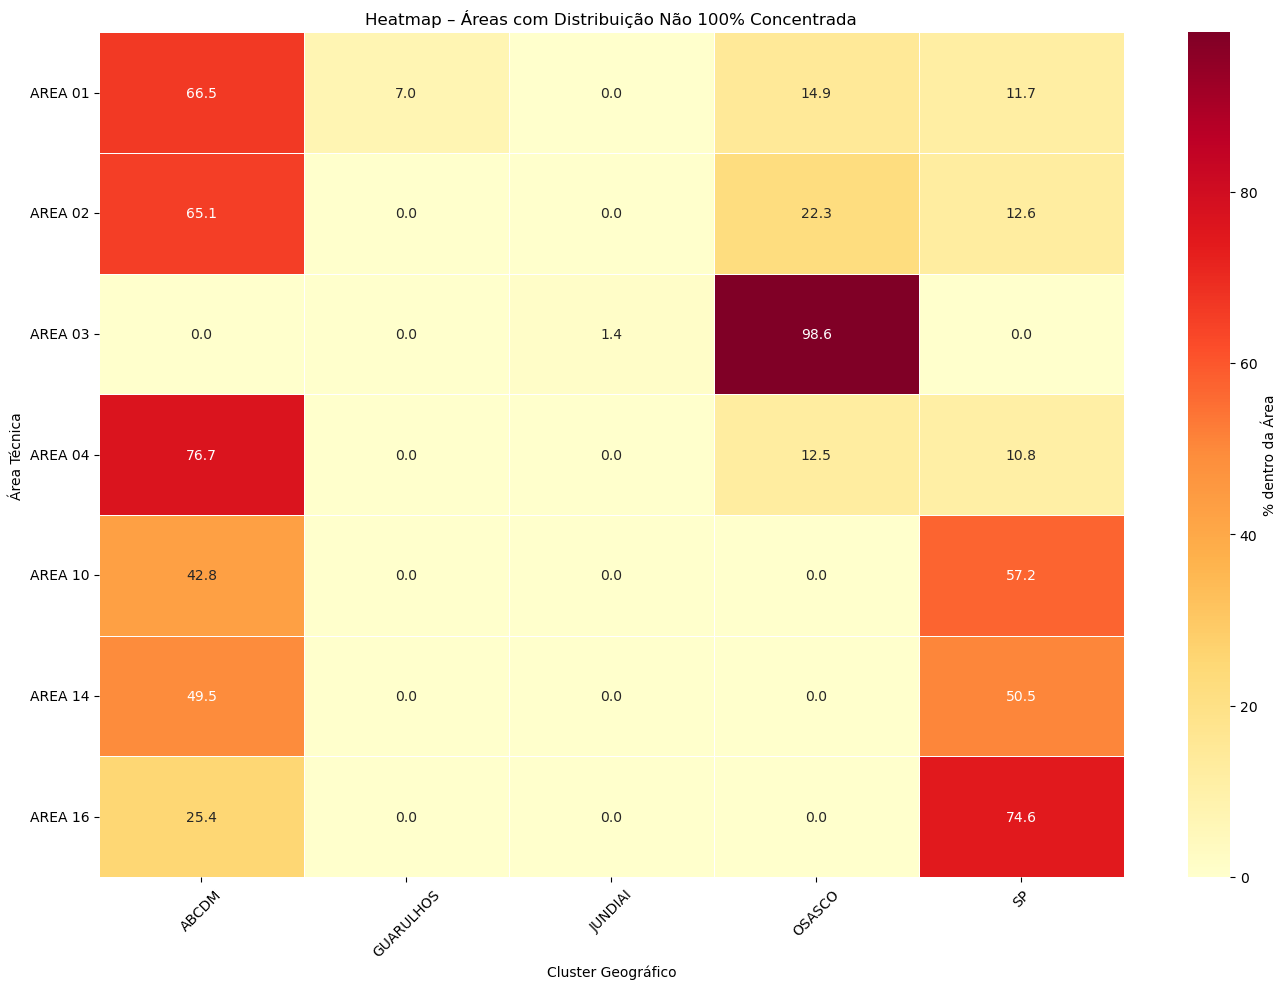

In [32]:
# Identificar concentração máxima por área
max_por_area = matriz_pct.max(axis=1)

# Filtrar apenas áreas que NÃO são 100% concentradas
matriz_parcial = matriz_pct[max_por_area < 100].copy()

plt.figure(figsize=(14, 10))

sns.heatmap(
    matriz_parcial,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "% dentro da Área"}
)

plt.title("Heatmap – Áreas com Distribuição Não 100% Concentrada")
plt.xlabel("Cluster Geográfico")
plt.ylabel("Área Técnica")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

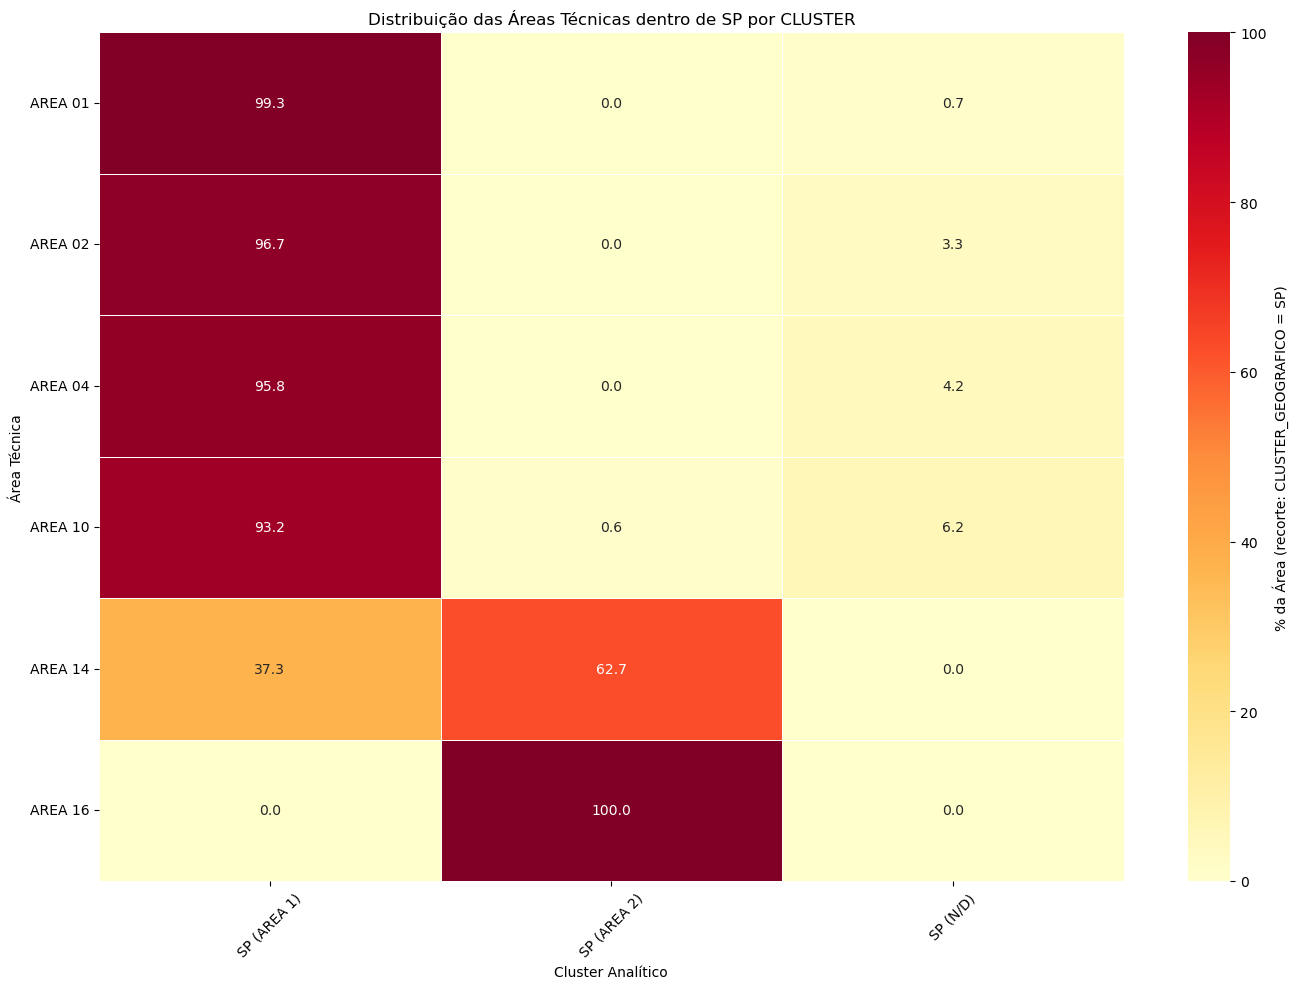

In [33]:
# --- Preparação e limpeza ---
df_aux = df.copy()

# Garantir tipo numérico
df_aux["HP_TECNICA"] = pd.to_numeric(df_aux["HP_TECNICA"], errors="coerce")

# Padronizar strings para evitar problemas de comparação
for col in ["CLUSTER_GEOGRAFICO", "CLUSTER_ANALITICO", "AREA_TECNICA"]:
    df_aux[col] = df_aux[col].astype(str).str.strip()

# --- Selecionar áreas que NÃO estão integralmente em SP ---
matriz_geo = df_aux.pivot_table(
    index="AREA_TECNICA",
    columns="CLUSTER_GEOGRAFICO",
    values="HP_TECNICA",
    aggfunc="sum",
    fill_value=0
)

matriz_geo_pct = (matriz_geo.div(matriz_geo.sum(axis=1), axis=0) * 100).fillna(0)

# Verificações de segurança
if "SP" not in matriz_geo_pct.columns:
    raise ValueError("Não há coluna 'SP' em CLUSTER_GEOGRAFICO após o pivot. Verifique valores (ex.: 'SP', 'Sp', 'SÃO PAULO').")

# Critério: áreas com participação em SP > 0 e < 100
areas_nao_integrais_em_SP = matriz_geo_pct.index[
    (matriz_geo_pct["SP"] > 0) & (matriz_geo_pct["SP"] < 100)
]

# --- Dentro do recorte SP, ver a distribuição por CLUSTER_ANALITICO ---
# Filtrar o DataFrame base para:
#   a) apenas as áreas selecionadas
#   b) somente CLUSTER_GEOGRAFICO == 'SP'
df_sp = df_aux.loc[
    df_aux["AREA_TECNICA"].isin(areas_nao_integrais_em_SP) &
    (df_aux["CLUSTER_GEOGRAFICO"] == "SP")
].copy()

if df_sp.empty:
    raise ValueError("Após o filtro (áreas não integrais em SP + recorte SP), não sobrou dado. Verifique a padronização de SP e as áreas.")

# Pivot: linhas = AREA_TECNICA, colunas = CLUSTER_ANALITICO, valores = soma HP
matriz_sp_analitico = df_sp.pivot_table(
    index="AREA_TECNICA",
    columns="CLUSTER_ANALITICO",
    values="HP_TECNICA",
    aggfunc="sum",
    fill_value=0
)

# Percentual linha a linha (100% por área *dentro de SP*)
matriz_sp_analitico_pct = (
    matriz_sp_analitico.div(matriz_sp_analitico.sum(axis=1), axis=0) * 100
).fillna(0).round(1)

# --- Visualização (heatmap) ---
plt.figure(figsize=(14, 10))
sns.heatmap(
    matriz_sp_analitico_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "% da Área (recorte: CLUSTER_GEOGRAFICO = SP)"}
)
plt.title("Distribuição das Áreas Técnicas dentro de SP por CLUSTER")
plt.xlabel("Cluster Analítico")
plt.ylabel("Área Técnica")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
# Importar novo banco que contem os bairros e a % de classe AB1 por bairro. Verificar quais são os bairros que estão na AREA 14

file_path = r"C:\Users\wnsos\OneDrive\Escritorio\Claro\Cluster_projeto_area_tecnica\bases\cluster_pc_ab1.xlsx"
df_cluster_ab1 = pd.read_excel(file_path, sheet_name="cluster_ab1")

# Ver primeiras linhas
df_cluster_ab1 .head()

c:\Users\wnsos\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,COD_NODE,COD_IBGE,DESC_CIDADE,CLUSTER_GEOGRAFICO,CIDADE_SUB_CLUSTER,ZONA,AREA,CHAVE_NODE_IBGE,PC_CLASSE_AB1
0,AALAA,3550308,SAO PAULO,SP,ARTUR ALVIM,ZL,Capital (Área 2),AALAA_3550308,5%
1,AALAAM,3550308,SAO PAULO,SP,ARTUR ALVIM,ZL,Capital (Área 2),AALAAM_3550308,5%
2,AALAB,3550308,SAO PAULO,SP,ARTUR ALVIM,ZL,Capital (Área 2),AALAB_3550308,5%
3,AALABM,3550308,SAO PAULO,SP,ARTUR ALVIM,ZL,Capital (Área 2),AALABM_3550308,5%
4,AALAC,3550308,SAO PAULO,SP,ARTUR ALVIM,ZL,Capital (Área 2),AALAC_3550308,5%


In [38]:
# Tratar a coluna de PC_CLASSE_AB1

# Fazer uma cópia para evitar SettingWithCopyWarning
df_cluster_ab1 = df_cluster_ab1.copy()

# Converter percentual para proporção (4% -> 0.04)
df_cluster_ab1["PC_CLASSE_AB1"] = (
    df_cluster_ab1["PC_CLASSE_AB1"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

df_cluster_ab1["PC_CLASSE_AB1"] = (
    pd.to_numeric(df_cluster_ab1["PC_CLASSE_AB1"], errors="coerce") / 100
)

In [39]:
# Selecionar variaveis de interesse
df_lookup = df_cluster_ab1[
    ["CHAVE_NODE_IBGE", "CIDADE_SUB_CLUSTER", "PC_CLASSE_AB1"]
].drop_duplicates()

In [40]:
# Fazer o merge pela chave para puxar o bairro e % de classe AB1

df = df.merge(
    df_lookup,
    on="CHAVE_NODE_IBGE",
    how="left"
)

In [41]:
df.head()

,DAT_MOVIMENTO,DESC_CIDADE,COD_NODE,COD_NODE_TRAT,COD_IBGE,COD_TIPO_EDIFICACAO,AREA_TECNICA,AREA,CLUSTER_GEOGRAFICO,CHAVE_NODE_IBGE,DESC_CIDADE_NORM,COD_NODE_NORM,HP_TECNICA,CLUSTER_ANALITICO,CIDADE_SUB_CLUSTER,PC_CLASSE_AB1
0,01/02/26,SAO PAULO,AALAA,AALAA,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAA_3550308,SAO PAULO,AALAA,967,SP (AREA 2),ARTUR ALVIM,0.05
1,01/02/26,SAO PAULO,AALAB,AALAB,3550308,MULTIPLO,AREA 53,Capital (Área 2),SP,AALAB_3550308,SAO PAULO,AALAB,967,SP (AREA 2),ARTUR ALVIM,0.05
2,01/02/26,SAO PAULO,AALAC,AALAC,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAC_3550308,SAO PAULO,AALAC,967,SP (AREA 2),ARTUR ALVIM,0.05
3,01/02/26,SAO PAULO,AALAD,AALAD,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAD_3550308,SAO PAULO,AALAD,967,SP (AREA 2),ARTUR ALVIM,0.05
4,01/02/26,SAO PAULO,AALAE,AALAE,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAE_3550308,SAO PAULO,AALAE,967,SP (AREA 2),ARTUR ALVIM,0.05


In [42]:
# Identificar os casos da Área 14

df_area14 = df[
    (df["AREA_TECNICA"] == "AREA 14") &
    (df["CLUSTER_ANALITICO"].isin(["SP (AREA 1)", "SP (AREA 2)"]))
]

In [43]:
# Criar tabela para visualizar os casos

tabela_bairros = (
    df_area14
    .groupby(["CLUSTER_ANALITICO", "CIDADE_SUB_CLUSTER"])
    .agg(
        HP_TOTAL=("HP_TECNICA", "sum"),
        PC_CLASSE_AB1=("PC_CLASSE_AB1", "mean")
    )
    .reset_index()
)

tabela_bairros = tabela_bairros.sort_values(
    ["CLUSTER_ANALITICO", "HP_TOTAL"],
    ascending=[True, False]
)

tabela_bairros

,CLUSTER_ANALITICO,CIDADE_SUB_CLUSTER,HP_TOTAL,PC_CLASSE_AB1
1,SP (AREA 1),SANTO AMARO,44482,0.25
0,SP (AREA 1),PINHEIROS,967,0.66
2,SP (AREA 2),SOCORRO,76393,0.04


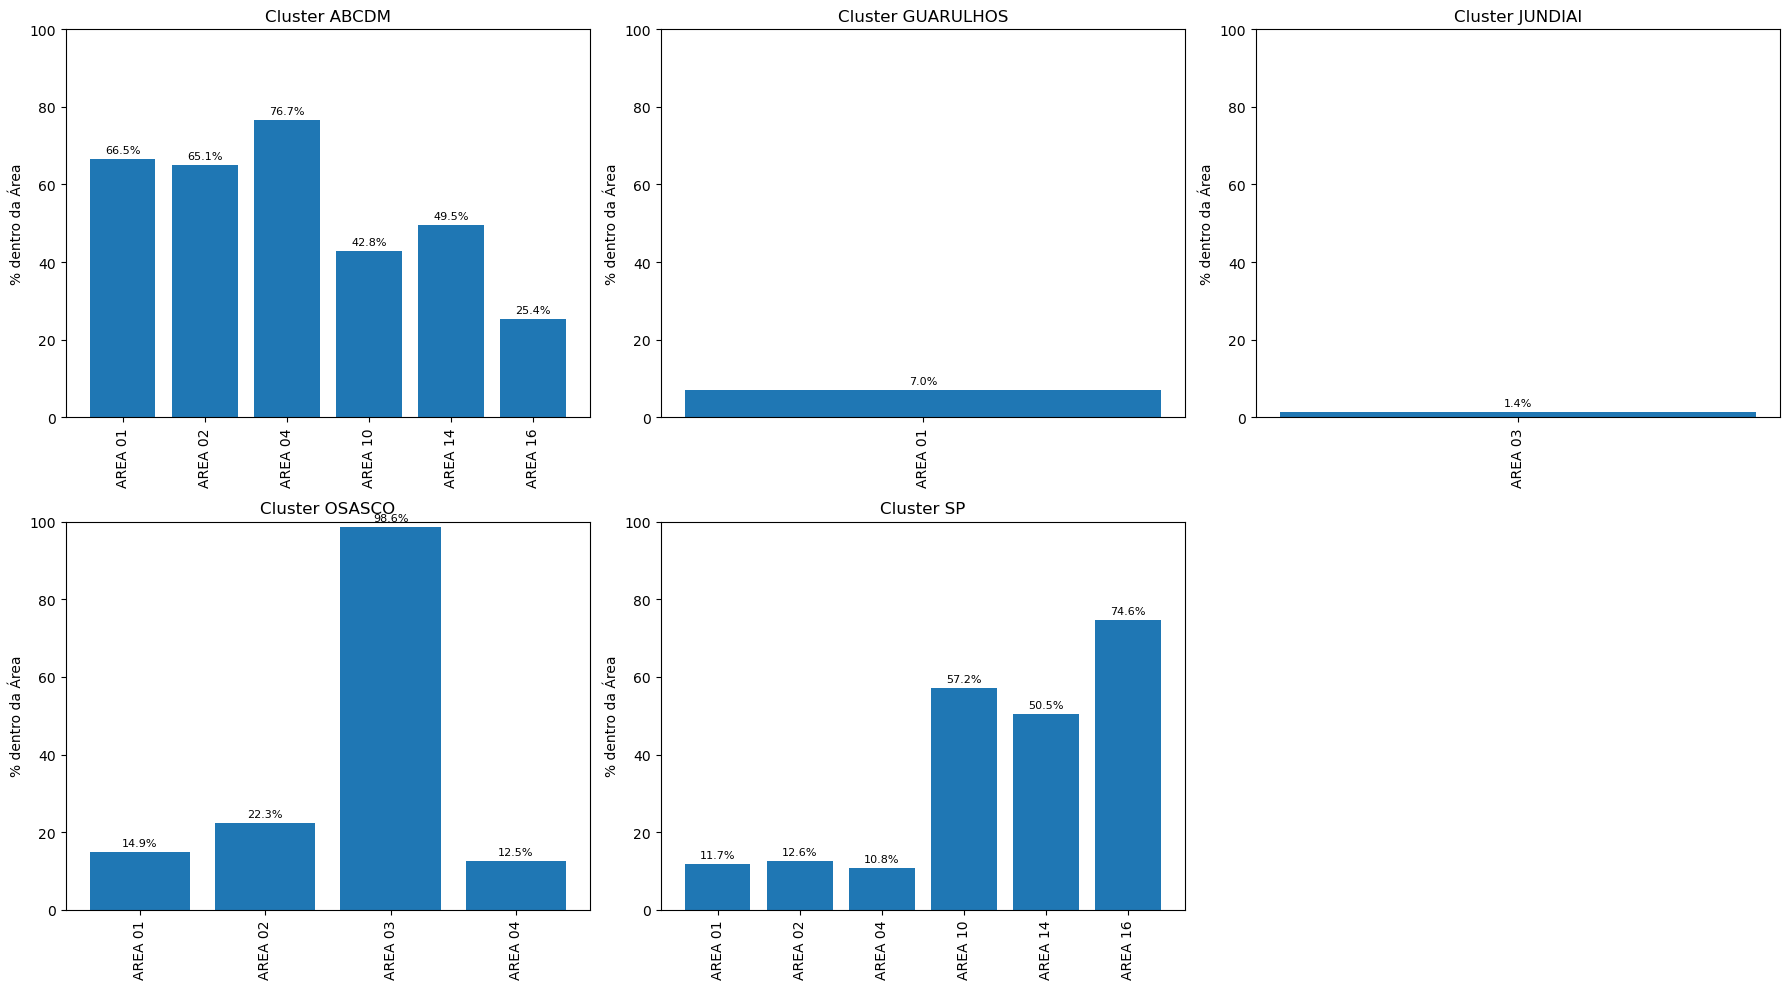

In [44]:
# Identificar áreas 100% concentradas
max_por_area = matriz_pct.max(axis=1)

# Manter apenas áreas NÃO 100%
matriz_nao_100 = matriz_pct[max_por_area < 100].copy()

clusters = matriz_nao_100.columns
n_clusters = len(clusters)

# Layout automático
n_cols = 3
n_rows = math.ceil(n_clusters / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, cluster in enumerate(clusters):
    
    data = matriz_nao_100[cluster]
    data = data[data > 0].sort_index() 

    bars = axes[i].bar(data.index, data.values)

    axes[i].set_title(f"Cluster {cluster}")
    axes[i].set_ylim(0, 100)
    axes[i].set_ylabel("% dentro da Área")
    axes[i].tick_params(axis='x', rotation=90)

    # Rótulos
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha='center',
            va='bottom',
            fontsize=8
        )

# Remover eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [45]:
# Identificar áreas 100%
max_por_area = matriz_pct.max(axis=1)

areas_100 = matriz_pct[max_por_area == 100].copy()

# Transformar para formato longo
areas_100_long = (
    areas_100
    .stack()
    .reset_index()
)

areas_100_long.columns = ["AREA_TECNICA", "CLUSTER_GEOGRAFICO", "PERCENTUAL"]

# Manter apenas onde é 100%
areas_100_long = areas_100_long[areas_100_long["PERCENTUAL"] == 100]

# Adicionar HP total da área
hp_total_area = matriz.sum(axis=1)

areas_100_long["HP_TOTAL"] = areas_100_long["AREA_TECNICA"].map(hp_total_area)

# Reordenar colunas (Cluster primeiro)
areas_100_long = areas_100_long[
    ["CLUSTER_GEOGRAFICO", "AREA_TECNICA", "HP_TOTAL"]
]

# Ordenar por cluster e depois por HP decrescente
areas_100_long = areas_100_long.sort_values(
    ["CLUSTER_GEOGRAFICO", "HP_TOTAL"],
    ascending=[True, False]
)

areas_100_long.head()

,CLUSTER_GEOGRAFICO,AREA_TECNICA,HP_TOTAL
5,ABCDM,AREA 08,144180
20,ABCDM,AREA 12,104554
10,ABCDM,AREA 09,103596
255,ABCDM,AREA RIBEIRAO P,40284
46,GUARULHOS,AREA 2,186387


In [46]:
# Filtrar o cluster SP

df_sp = df[df["CLUSTER_GEOGRAFICO"] == "SP"].copy()

df_sp["HP_TECNICA"] = pd.to_numeric(df_sp["HP_TECNICA"], errors='coerce')

In [47]:
# # Criar matriz completa

matriz_cluster = df.pivot_table(
index="AREA_TECNICA",
columns="CLUSTER_ANALITICO",
values="HP_TECNICA",
aggfunc="sum",
fill_value=0
)

matriz_cluster_pct = (matriz_cluster.div(matriz_cluster.sum(axis=1), axis=0) * 100
                     ).fillna(0).round(1)
matriz_cluster_pct 

CLUSTER_ANALITICO,ABCDM,GUARULHOS,JUNDIAI,OSASCO,SP (AREA 1),SP (AREA 2),SP (N/D)
AREA_TECNICA,,,,,,,
AREA 01,66.5,7.0,0.0,14.9,11.6,0.0,0.1
AREA 02,65.1,0.0,0.0,22.3,12.1,0.0,0.4
AREA 03,0.0,0.0,1.4,98.6,0.0,0.0,0.0
AREA 04,76.7,0.0,0.0,12.5,10.4,0.0,0.5
AREA 05,0.0,0.0,0.0,0.0,94.2,0.0,5.8
...,...,...,...,...,...,...,...
AREA VARGEM GRA,0.0,0.0,0.0,100.0,0.0,0.0,0.0
AREA VARZEA PAU,0.0,0.0,100.0,0.0,0.0,0.0,0.0
ATI,0.0,0.0,100.0,0.0,0.0,0.0,0.0


In [48]:
# Identifcar colunas do cluster SP

colunas_sp = [c for c in matriz_cluster_pct.columns if "SP" in c]

matriz_only_sp = matriz_cluster_pct[
    matriz_cluster_pct[colunas_sp].sum(axis=1) > 0
]

matriz_only_sp

CLUSTER_ANALITICO,ABCDM,GUARULHOS,JUNDIAI,OSASCO,SP (AREA 1),SP (AREA 2),SP (N/D)
AREA_TECNICA,,,,,,,
AREA 01,66.5,7.0,0.0,14.9,11.6,0.0,0.1
AREA 02,65.1,0.0,0.0,22.3,12.1,0.0,0.4
AREA 04,76.7,0.0,0.0,12.5,10.4,0.0,0.5
AREA 05,0.0,0.0,0.0,0.0,94.2,0.0,5.8
AREA 10,42.8,0.0,0.0,0.0,53.3,0.3,3.6
AREA 13,0.0,0.0,0.0,0.0,98.2,0.0,1.8
AREA 14,49.5,0.0,0.0,0.0,18.8,31.7,0.0
AREA 15,0.0,0.0,0.0,0.0,0.0,100.0,0.0
AREA 16,25.4,0.0,0.0,0.0,0.0,74.6,0.0


## CODIGO PARA CONVERTER O CLUSTER DE NEGOCIO, USANDO O DA AREA TECNICA, PARA A NOVA CLUSTERIZAÇÃO ##

In [49]:
# Criar a relação da nova clusterização com a área técnica

alto_valor = [
"AREA 01","AREA 02","AREA 04","AREA 05","AREA 10","AREA 13","AREA 17",
"AREA 19","AREA 20","AREA 21","AREA 23","AREA 28","AREA 30","AREA 41",
"AREA 46","AREA 49"
]

massivo = [
"AREA 14","AREA 15","AREA 16","AREA 34","AREA 35","AREA 37",
"AREA 39","AREA 40","AREA 48","AREA 51","AREA 53","AREA 54",
"AREA 55","AREA 56"
]

In [50]:
# Criar a função de classificação

def definir_cluster(row):

    cluster_geo = row["CLUSTER_GEOGRAFICO"]
    cidade = row["DESC_CIDADE"]
    area = row["AREA_TECNICA"]

    # EXCEÇÃO: SAO CAETANO DO SUL
    if cidade == "SAO CAETANO DO SUL":

        return pd.Series([
            "ALTO_VALOR",
            "SAO CAETANO DO SUL"
        ])

    # CASOS FORA DE SP
    if cluster_geo != "SP":

        return pd.Series([
            "METROPOLITANA",
            cidade
        ])

    # CASOS SP ALTO VALOR
    if cluster_geo == "SP" and area in alto_valor:

        return pd.Series([
            "ALTO_VALOR",
            area
        ])

    # CASOS SP MASSIVO
    if cluster_geo == "SP" and area in massivo:

        return pd.Series([
            "MASSIVO",
            area
        ])

    # fallback
    return pd.Series([
        "OUTRO",
        area
    ])

In [51]:
# Criar novas colunas

df[["CLUSTER","SUBCLUSTER"]] = df.apply(definir_cluster, axis=1)

In [52]:
# Verificar resultado

df[["CLUSTER","SUBCLUSTER"]] = df.apply(definir_cluster, axis=1)

In [53]:
# Validação

df[['DESC_CIDADE', 'AREA_TECNICA', 'CLUSTER', 'SUBCLUSTER']].sample(n=10, random_state=42)

,DESC_CIDADE,AREA_TECNICA,CLUSTER,SUBCLUSTER
27134,ITATIBA,AREA ITATIBA,METROPOLITANA,ITATIBA
22818,SAO PAULO,AREA 34,MASSIVO,AREA 34
4252,JARINU,AREA JARINU,METROPOLITANA,JARINU
5047,RIBEIRAO PIRES,AREA RIBEIRAO P,METROPOLITANA,RIBEIRAO PIRES
17409,CAIEIRAS,AREA CAIEIRAS,METROPOLITANA,CAIEIRAS
5460,SAO PAULO,AREA 04,ALTO_VALOR,AREA 04
11222,ARUJA,AREA ARUJA,METROPOLITANA,ARUJA
20365,SAO PAULO,AREA 20,ALTO_VALOR,AREA 20
10497,ARUJA,AREA ARUJA,METROPOLITANA,ARUJA
28728,ITATIBA,AREA ITATIBA,METROPOLITANA,ITATIBA


In [54]:
# Validação para quando SUBCLUSTER é SAO CAETANO DO SUL

df[df['DESC_CIDADE'] == 'SAO CAETANO DO SUL'][['DESC_CIDADE', 'AREA_TECNICA', 'CLUSTER', 'SUBCLUSTER']].drop_duplicates()

,DESC_CIDADE,AREA_TECNICA,CLUSTER,SUBCLUSTER
21136,SAO CAETANO DO SUL,AREA 12,ALTO_VALOR,SAO CAETANO DO SUL


In [55]:
df.head()

,DAT_MOVIMENTO,DESC_CIDADE,COD_NODE,COD_NODE_TRAT,COD_IBGE,COD_TIPO_EDIFICACAO,AREA_TECNICA,AREA,CLUSTER_GEOGRAFICO,CHAVE_NODE_IBGE,DESC_CIDADE_NORM,COD_NODE_NORM,HP_TECNICA,CLUSTER_ANALITICO,CIDADE_SUB_CLUSTER,PC_CLASSE_AB1,CLUSTER,SUBCLUSTER
0,01/02/26,SAO PAULO,AALAA,AALAA,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAA_3550308,SAO PAULO,AALAA,967,SP (AREA 2),ARTUR ALVIM,0.05,MASSIVO,AREA 53
1,01/02/26,SAO PAULO,AALAB,AALAB,3550308,MULTIPLO,AREA 53,Capital (Área 2),SP,AALAB_3550308,SAO PAULO,AALAB,967,SP (AREA 2),ARTUR ALVIM,0.05,MASSIVO,AREA 53
2,01/02/26,SAO PAULO,AALAC,AALAC,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAC_3550308,SAO PAULO,AALAC,967,SP (AREA 2),ARTUR ALVIM,0.05,MASSIVO,AREA 53
3,01/02/26,SAO PAULO,AALAD,AALAD,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAD_3550308,SAO PAULO,AALAD,967,SP (AREA 2),ARTUR ALVIM,0.05,MASSIVO,AREA 53
4,01/02/26,SAO PAULO,AALAE,AALAE,3550308,UNICO,AREA 53,Capital (Área 2),SP,AALAE_3550308,SAO PAULO,AALAE,967,SP (AREA 2),ARTUR ALVIM,0.05,MASSIVO,AREA 53


In [56]:
df_final = df[['COD_NODE_TRAT', 'COD_IBGE', 'DESC_CIDADE', 'CLUSTER', 'SUBCLUSTER']]

In [ ]:
## Exportar a tabela df_final para Excel

#output_path = r"C:\Users\wnsos\OneDrive\Escritorio\Claro\Cluster_projeto_area_tecnica\distribuicao_area_SP_node_tratado.xlsx"
#df_final.to_excel(output_path, index=False)

In [ ]:
#  Exportar a base final para Excel e rodar no app do Streamlit

# print("Total de linhas:", len(df))
# print("Colunas:", df.columns.tolist())
# print("Valores nulos:\n", df.isnull().sum())

# df.to_csv(r"C:\Users\wnsos\OneDrive\Escritorio\Claro\Cluster_projeto_area_tecnica\bases\clusterizacao_streamlit.csv", index=False, sep=";", encoding="utf-8-sig")